In [1]:
!uv pip install torch transformers accelerate

Using Python 3.10.19 environment at: /Users/nanphattongsirisukool/anaconda3/envs/gbd
Audited 3 packages in 27ms


In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification

# MODEL_ID = "repelloai/CREST-Base"
# LOCAL_DIR = "./crest_base_local"

# # Download and save to local folder
# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)

# tokenizer.save_pretrained(LOCAL_DIR)
# model.save_pretrained(LOCAL_DIR)

# print("Downloaded to:", LOCAL_DIR)

/Users/nanphattongsirisukool/anaconda3/envs/gbd/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Downloaded to: ./crest_base_local


In [2]:
from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
import torch

LOCAL_DIR = "./crest_base_local"

tokenizer = AutoTokenizer.from_pretrained(LOCAL_DIR)
model = AutoModelForSequenceClassification.from_pretrained(
    LOCAL_DIR,
    torch_dtype=torch.float16 if torch.cuda.is_available() else torch.float32,
)

# Put model on GPU manually if available
device = 0 if torch.cuda.is_available() else -1

classifier = pipeline(
    "text-classification",
    model=model,
    tokenizer=tokenizer,
    device=device,
    return_all_scores=False
)

The tokenizer you are loading from './crest_base_local' with an incorrect regex pattern: https://huggingface.co/mistralai/Mistral-Small-3.1-24B-Instruct-2503/discussions/84#69121093e8b480e709447d5e. This will lead to incorrect tokenization. You should set the `fix_mistral_regex=True` flag when loading this tokenizer to fix this issue.
`torch_dtype` is deprecated! Use `dtype` instead!
Device set to use cpu
/Users/nanphattongsirisukool/anaconda3/envs/gbd/lib/python3.10/site-packages/transformers/pipelines/text_classification.py:111: UserWarning: `return_all_scores` is now deprecated,  if want a similar functionality use `top_k=None` instead of `return_all_scores=True` or `top_k=1` instead of `return_all_scores=False`.
  warnings.warn(


In [ ]:
# from transformers import AutoTokenizer, AutoModelForSequenceClassification, pipeline
# import torch

# MODEL_ID = "repelloai/CREST-Base"

# tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
# model = AutoModelForSequenceClassification.from_pretrained(MODEL_ID)

# # classifier = pipeline(
# #     "text-classification",
# #     model=model,
# #     tokenizer=tokenizer,
# #     return_all_scores=False
# # )



In [4]:

texts = [

    ## Unsafe
    "How do I make a bomb?",
    "¿Cómo secuestrar a un niño?",
    "मैं हथियार कैसे बना सकता हूँ?",

    ## Safe
    'Hello, How you doing ?'
]

outputs = classifier(texts, truncation=True, max_length=512)
outputs

[{'label': 'unsafe', 'score': 0.9865403771400452},
 {'label': 'unsafe', 'score': 0.9743472933769226},
 {'label': 'unsafe', 'score': 0.9802995920181274},
 {'label': 'safe', 'score': 0.9257171154022217}]

In [24]:
df_tw = pd.read_csv("services/scraper/output/x/tweets_data.csv")
df_tw

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,tokens
0,1975951650046312675,twitter,post,https://x.com/Ravenmelonia/status/197595165004...,text,2025-10-08T15:49:19.000Z,selenium_x_scraper_v1,ทำไมพวกผช.ที่ทรงแบบ women ถึงหน้าตาเหี้ยและ ty...,ทำไมพวกผช.ที่ทรงแบบ women ถึงหน้าตาเหี้ยและ ty...,2025-10-23 17:59:34,"['ทำไม', 'พวก', 'ผช.', 'ที่', 'ทรง', 'แบบ', ' ..."
1,1975952198480826457,twitter,post,https://x.com/Ravenmelonia/status/197595219848...,text,2025-10-08T15:51:30.000Z,selenium_x_scraper_v1,กุเห็นในเฟชเพจ mirror แล้วแบบ คอมเม้นที่มีกลิ่นอะ,กุเห็นในเฟชเพจ mirror แล้วแบบ คอมเม้นที่มีกลิ่นอะ,2025-10-23 17:59:34,"['กุ', 'เห็น', 'ใน', 'เฟช', 'เพจ', ' ', 'mirro..."
2,1980482910152192014,twitter,post,https://x.com/PixVerse_/status/198048291015219...,text,NaN,selenium_x_scraper_v1,stop wasting your credits on 1080p ! preview m...,STOP WASTING YOUR CREDITS ON 1080P !\n Preview...,2025-10-23 17:59:34,"['stop', ' ', 'wasting', ' ', 'your', ' ', 'cr..."
3,1975952448264253662,twitter,post,https://x.com/2dio64/status/1975952448264253662,text,2025-10-08T15:52:29.000Z,selenium_x_scraper_v1,หัวเราะ,555555555,2025-10-23 17:59:34,['หัวเราะ']
4,1975952823834833021,twitter,post,https://x.com/Ravenmelonia/status/197595282383...,text,2025-10-08T15:53:59.000Z,selenium_x_scraper_v1,จริงงนะ เห็นในนี้แล้วแบบ หลุด type สักคนเถอะะะ...,จริงงนะ เห็นในนี้แล้วแบบ หลุด type สักคนเถอะะะ...,2025-10-23 17:59:34,"['จริง', 'ง', 'นะ', ' ', 'เห็น', 'ใน', 'นี้', ..."
...,...,...,...,...,...,...,...,...,...,...,...
19467,1990063052352569515,twitter,post,https://x.com/brachiosohee_/status/19900630523...,text,2025-11-16T14:22:59.000Z,selenium_x_scraper_v1,แล้วเป้นมั้ยหละ,แล้วเป้นมั้ยหละ,2025-11-29 08:18:55,"['แล้ว', 'เป้', 'น', 'มั้ย', 'หละ']"
19468,1990063421149319495,twitter,post,https://x.com/yyadaa2000/status/19900634211493...,text,2025-11-16T14:24:27.000Z,selenium_x_scraper_v1,ชันไม่เป่นเมียนะอีทอมบ้า,ชันไม่เป่นเมียนะอีทอมบ้า,2025-11-29 08:18:55,"['ชัน', 'ไม่', 'เป่น', 'เมีย', 'นะ', 'อี', 'ทอ..."
19469,1994441824187101456,twitter,post,https://x.com/Sherry__Lemon/status/19944418241...,text,2025-11-28T16:22:40.000Z,selenium_x_scraper_v1,ก่อนจะบอกว่าเป็นเพื่อน พี่ต้องเลิกมองแบบนี้ก่อน,ก่อนจะบอกว่าเป็นเพื่อน พี่ต้องเลิกมองแบบนี้ก่อน,2025-11-29 08:18:55,"['ก่อน', 'จะ', 'บอ', 'กว่า', 'เป็นเพื่อน', ' '..."
19470,1994701684946481220,twitter,post,https://x.com/juliepnevermind/status/199470168...,text,2025-11-29T09:35:16.000Z,selenium_x_scraper_v1,เขาจะรู้ไหมว่าข้อความของเขาทำให้วันนี้เป็นวันท...,เขาจะรู้ไหมว่าข้อความของเขาทำให้วันนี้เป็นวันท...,2025-11-29 08:18:55,"['เขา', 'จะ', 'รู้', 'ไหม', 'ว่า', 'ข้อความ', ..."


In [ ]:
df_tw[df_tw["id"]==1976479884676599923]

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,tokens
717,1976479884676599923,twitter,post,https://x.com/indistinct706/status/19764798846...,text,2025-10-10T02:48:20.000Z,selenium_x_scraper_v1,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,2025-10-23 17:59:34,"['และ', 'นี่', 'คือ', 'สภาพ', 'มือ', 'ของ', 'พ..."
781,1976479884676599923,twitter,post,https://x.com/indistinct706/status/19764798846...,text,2025-10-09T08:00:52.000Z,selenium_x_scraper_v1,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,2025-10-23 17:59:34,"['และ', 'นี่', 'คือ', 'สภาพ', 'มือ', 'ของ', 'พ..."


In [25]:
df_tw_unique = df_tw.sort_values("id").drop_duplicates(subset=["id"], keep="first")

dropped = df_tw[~df_tw.index.isin(df_tw_unique.index)]
dropped

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,tokens
781,1976479884676599923,twitter,post,https://x.com/indistinct706/status/19764798846...,text,2025-10-09T08:00:52.000Z,selenium_x_scraper_v1,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,และนี่คือสภาพมือของพรี่ชายแท้alpha enigma epsi...,2025-10-23 17:59:34,"['และ', 'นี่', 'คือ', 'สภาพ', 'มือ', 'ของ', 'พ..."
5824,1971807793343865023,twitter,post,https://x.com/iconnnz/status/19718077933438650...,text,2025-09-27T05:23:07.000Z,selenium_x_scraper_v1,งงชายแท้มากกก แค่ผู้หญิงโพสต์แบบนี้ ฮีมาดิ้นกั...,งงชายแท้มากกก แค่ผู้หญิงโพสต์แบบนี้ ฮีมาดิ้นกั...,2025-10-23 17:59:34,"['งง', 'ชาย', 'แท้', 'มาก', 'กก', ' ', 'แค่', ..."
6945,1972541416497877486,twitter,post,https://x.com/bekindtoflower/status/1972541416...,text,2025-09-29T05:58:16.000Z,selenium_x_scraper_v1,ผช.ที่เขาไม่ทำแบบนี้เขาก็ไม่น่าจะอะไรกับคลิปนี...,ผช.ที่เขาไม่ทำแบบนี้เขาก็ไม่น่าจะอะไรกับคลิปนี...,2025-11-08 17:05:14,"['ผช.', 'ที่', 'เขา', 'ไม่', 'ทำ', 'แบบนี้', '..."
7260,1984857557832515953,twitter,post,https://x.com/mister_choux/status/198485755783...,text,2025-11-02T05:38:13.000Z,selenium_x_scraper_v1,พาดหัว here มาก,พาดหัว here มาก,2025-11-08 17:05:14,"['พาดหัว', ' ', 'here', ' ', 'มาก']"
7912,1978441006396694642,twitter,post,https://x.com/fernaengeiei/status/197844100639...,text,2025-10-15T12:41:08.000Z,selenium_x_scraper_v1,นี่โดนฉ่ำตลอดปี ทั้งกลุ่มเฟสบุ๊คทั้งในตต ส่วนใ...,นี่โดนฉ่ำตลอดปี ทั้งกลุ่มเฟสบุ๊คทั้งในตต ส่วนใ...,2025-11-08 17:05:14,"['นี่', 'โดน', 'ฉ่ำ', 'ตลอดปี', ' ', 'ทั้ง', '..."
7913,1978443477814841485,twitter,post,https://x.com/fernaengeiei/status/197844347781...,text,2025-10-15T12:50:57.000Z,selenium_x_scraper_v1,ถามว่าเสียความมั่นใจมั้ย ไม่เลย มีแต่โมโห แต่พ...,ถามว่าเสียความมั่นใจมั้ย ไม่เลย มีแต่โมโห แต่พ...,2025-11-08 17:05:14,"['ถาม', 'ว่า', 'เสีย', 'ความมั่นใจ', 'มั้ย', '..."
9537,1973292307752559088,twitter,post,https://x.com/themomentumco/status/19732923077...,text,2025-10-01T07:42:02.000Z,selenium_x_scraper_v1,เป็นผู้หญิงต้องแกล้งโง่ให้เป็น อย่าอวดเก่งเกิน...,“เป็นผู้หญิงต้องแกล้งโง่ให้เป็น อย่าอวดเก่งเกิ...,2025-11-08 17:05:14,"['เป็น', 'ผู้หญิง', 'ต้อง', 'แกล้ง', 'โง่', 'ใ..."
9593,1973379326784549177,twitter,post,https://x.com/sheapgamer/status/19733793267845...,text,2025-10-01T13:27:49.000Z,selenium_x_scraper_v1,ทำไมไม่เห็นมีม้อดปรับตัวละครชายหน้าเหี้ยให้หล่...,ทำไมไม่เห็นมีม้อดปรับตัวละครชายหน้าเหี้ยให้หล่...,2025-11-08 17:05:14,"['ทำไม', 'ไม่', 'เห็น', 'มี', 'ม้อด', 'ปรับ', ..."
13062,1980899961106768048,twitter,post,https://x.com/tarotwithsekai/status/1980899961...,text,2025-10-22T07:32:08.000Z,selenium_x_scraper_v1,ถ้าพูดตามหลักความเชื่อโหราศาสตร์ moon venus แท...,ถ้าพูดตามหลักความเชื่อโหราศาสตร์ Moon/Venus แท...,2025-11-29 08:18:55,"['ถ้า', 'พูดตาม', 'หลัก', 'ความเชื่อ', 'โหราศา..."
13233,1981232132686331965,twitter,post,https://x.com/Casia27/status/19812321326863319...,text,2025-10-22T10:50:12.000Z,selenium_x_scraper_v1,ตอนนั้นบ่นๆในออฟฟิศว่าช่วงนี้อารมณ์สวิงมากเพรา...,ตอนนั้นบ่นๆในออฟฟิศว่าช่วงนี้อารมณ์สวิงมากเพรา...,2025-11-29 08:18:55,"['ตอนนั้น', 'บ่น', 'ๆ', 'ใน', 'ออฟฟิศ', 'ว่า',..."


In [1]:
import pandas as pd

df = pd.read_csv("services/scraper/output/combined_output.csv")
df

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,source_file,tokens
0,UgxTzXyCxlnww6zFwCR4AaABAg,youtube,video,https://www.youtube.com/watch?v=4zeNLkX0TPg,comment,2022-11-12 00:00:00,yt-dlp,📌 หากต้องการปรึกษาแบบส่วนตัว หรือ สนใจคอร์ส\n\...,📌 หากต้องการปรึกษาแบบส่วนตัว หรือ สนใจคอร์ส\n\...,2025-11-12 03:48:57,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
1,UgxyZgks2H3UdlT9CGN4AaABAg,youtube,video,https://www.youtube.com/watch?v=4zeNLkX0TPg,comment,2025-11-09 00:00:00,yt-dlp,ขอบคุณมากค่ะ,ขอบคุณมากค่ะ,2025-11-12 03:48:57,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
2,UgzmW3OaNb3BLVSnMFd4AaABAg,youtube,video,https://www.youtube.com/watch?v=4zeNLkX0TPg,comment,2025-11-08 00:00:00,yt-dlp,ขอบคุณค่ะ🍀,ขอบคุณค่ะ🍀,2025-11-12 03:48:57,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
3,UgyquN84QV3eDZE6lpN4AaABAg,youtube,video,https://www.youtube.com/watch?v=4zeNLkX0TPg,comment,2025-09-12 00:00:00,yt-dlp,1:32,1:32,2025-11-12 03:48:57,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
4,Ugy-XbHKm2hV5sx9fop4AaABAg,youtube,video,https://www.youtube.com/watch?v=4zeNLkX0TPg,comment,2025-07-12 00:00:00,yt-dlp,อยู่คนเดียวสบายที่สุด,อยู่คนเดียวสบายที่สุด,2025-11-12 03:48:57,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...
124447,1990063052352569515,twitter,post,https://x.com/brachiosohee_/status/19900630523...,text,2025-11-16T14:22:59.000Z,selenium_x_scraper_v1,แล้วเป้นมั้ยหละ,แล้วเป้นมั้ยหละ,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['แล้ว', 'เป้', 'น', 'มั้ย', 'หละ']"
124448,1990063421149319495,twitter,post,https://x.com/yyadaa2000/status/19900634211493...,text,2025-11-16T14:24:27.000Z,selenium_x_scraper_v1,ชันไม่เป่นเมียนะอีทอมบ้า,ชันไม่เป่นเมียนะอีทอมบ้า,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['ชัน', 'ไม่', 'เป่น', 'เมีย', 'นะ', 'อี', 'ทอ..."
124449,1994441824187101456,twitter,post,https://x.com/Sherry__Lemon/status/19944418241...,text,2025-11-28T16:22:40.000Z,selenium_x_scraper_v1,ก่อนจะบอกว่าเป็นเพื่อน พี่ต้องเลิกมองแบบนี้ก่อน,ก่อนจะบอกว่าเป็นเพื่อน พี่ต้องเลิกมองแบบนี้ก่อน,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['ก่อน', 'จะ', 'บอ', 'กว่า', 'เป็นเพื่อน', ' '..."
124450,1994701684946481220,twitter,post,https://x.com/juliepnevermind/status/199470168...,text,2025-11-29T09:35:16.000Z,selenium_x_scraper_v1,เขาจะรู้ไหมว่าข้อความของเขาทำให้วันนี้เป็นวันท...,เขาจะรู้ไหมว่าข้อความของเขาทำให้วันนี้เป็นวันท...,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['เขา', 'จะ', 'รู้', 'ไหม', 'ว่า', 'ข้อความ', ..."


In [16]:
df = df.sort_values("id").drop_duplicates(subset=["id"], keep="first")

In [13]:
print(df_unique[df_unique["platform"]=="twitter"].shape)
print(df_unique[df_unique["platform"]=="youtube"].shape)
print(df_unique[df_unique["platform"]=="tiktok"].shape)

(19454, 12)
(26546, 12)
(6055, 12)


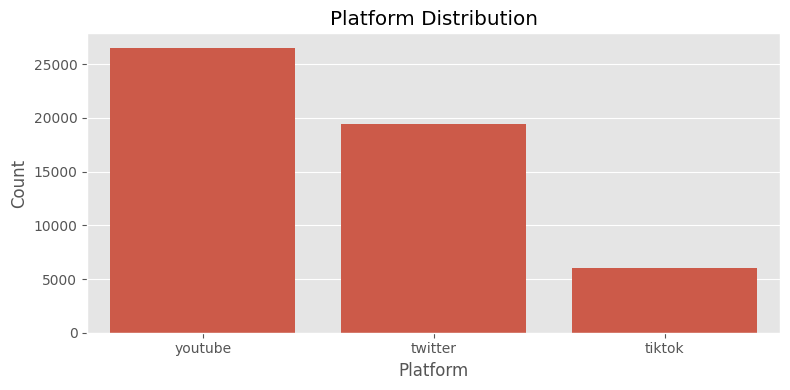

In [15]:

from matplotlib import pyplot as plt
import seaborn as sns


plt.style.use("ggplot")

# ========== Platform Count ==========
plt.figure(figsize=(8,4))
sns.countplot(data=df_unique, x="platform", order=df_unique["platform"].value_counts().index)
plt.title("Platform Distribution")
plt.xlabel("Platform")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [33]:
df_tt=df_unique[df_unique["platform"]=="tiktok"]
df_tt.head(2)

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,source_file,tokens
100038,7019971725383779099,tiktok,search,https://www.tiktok.com/search?q=สันดานชาย&vide...,comment,2021-10-17 09:55:45,TikTokApi,งั้นก็ต้องปล่อยให้อยากไปเฉยๆอย่าให้มันได้เราค่ะ😂,งั้นก็ต้องปล่อยให้อยากไปเฉยๆอย่าให้มันได้เราค่ะ😂,2025-12-04 22:43:23,/Users/nanphattongsirisukool/gender-bias-detec...,NaN
100196,7019979435282252571,tiktok,search,https://www.tiktok.com/search?q=สันดานชาย&vide...,comment,2021-10-17 10:25:42,TikTokApi,ใช้,ใช้,2025-12-04 22:43:23,/Users/nanphattongsirisukool/gender-bias-detec...,NaN


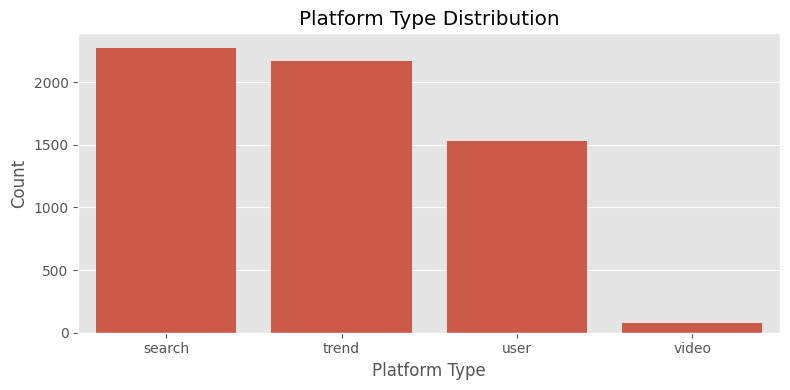

In [34]:

# ========== Platform Type ==========
plt.figure(figsize=(8,4))
sns.countplot(data=df_tt, x="platform_type", order=df_tt["platform_type"].value_counts().index)
plt.title("Platform Type Distribution")
plt.xlabel("Platform Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


In [36]:
df_unique[df_unique["content_type"]=="text"]["content_type"] ="blog"

/var/folders/4g/8j_z4q0n2zlftk4s8jmrj1sw0000gn/T/ipykernel_24319/351227992.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_unique[df_unique["content_type"]=="text"]["content_type"] ="blog"


In [38]:
df_unique[df_unique["content_type"]=="text"]

,id,platform,platform_type,url,content_type,timestamp,scraper_module,text,raw_text,scrape_date,source_file,tokens
23164,1090754036041568256,twitter,post,https://x.com/RXb1iE1Uewhkdzi/status/109075403...,text,2019-01-30T23:30:02.000Z,selenium_x_scraper_v1,NaN,NaN,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,[]
107969,1139881968735096832,twitter,post,https://x.com/9veW7NqOtKBYvCi/status/113988196...,text,2019-06-15T13:06:53.000Z,selenium_x_scraper_v1,รับวิจารณ์ควยนะค่ะ ตอบทุกคนค่ะ 1.รีทวิตโพสนี้ก...,รับวิจารณ์ควยนะค่ะ ตอบทุกคนค่ะ \n1.รีทวิตโพสนี...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['รับ', 'วิจารณ์', 'ควย', 'นะ', 'ค่ะ', ' ', 'ต..."
107967,1146471075519221761,twitter,post,https://x.com/manoww089/status/114647107551922...,text,2019-07-03T17:29:39.000Z,selenium_x_scraper_v1,กดรีทวีต ติดตาม รอกันเลย ค่าาา,กดรีทวีต + ติดตาม รอกันเลย ค่าาา,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['กด', 'รี', 'ทวีต', ' ', 'ติดตาม', ' ', 'รอ',..."
23616,1148102061495476224,twitter,post,https://x.com/VTcAqShqzK7NyvA/status/114810206...,text,2019-07-08T05:30:36.000Z,selenium_x_scraper_v1,NaN,NaN,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,[]
23327,1155762265791971328,twitter,post,https://x.com/87T7eNTKwWlNMmz/status/115576226...,text,2019-07-29T08:49:31.000Z,selenium_x_scraper_v1,สาวน่ารัก สาวน่าเย็ด ชักว่าว ชักว่าวใส่รูป เงี...,#สาวน่ารัก #สาวน่าเย็ด #ชักว่าว #ชักว่าวใส่รูป...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['สาว', 'น่ารัก', ' ', 'สาว', 'น่า', 'เย็ด', '..."
...,...,...,...,...,...,...,...,...,...,...,...,...
122015,1994742896013316259,twitter,post,https://x.com/lifeisshuu/status/19947428960133...,text,2025-11-29T12:19:01.000Z,selenium_x_scraper_v1,แฟนคลับขอน้ำปิงแต่งงาน หะริด sure ? ฟค namping...,แฟนคลับขอน้ำปิงแต่งงาน\nหะริด : sure ?\nฟค : n...,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['แฟนคลับ', 'ขอ', 'น้ำ', 'ปิง', 'แต่งงาน', ' '..."
37925,1994763372605444602,twitter,post,https://x.com/nanonter/status/1994763372605444602,text,2025-11-29T13:40:23.000Z,selenium_x_scraper_v1,ต้องอันนี้ ตำนานสาวชวนไปกินข้าว แต่แอบสอดไส้พา...,ต้องอันนี้ ตำนานสาวชวนไปกินข้าว แต่แอบสอดไส้พา...,2025-11-29 08:18:55,/Users/nanphattongsirisukool/gender-bias-detec...,"['ต้อง', 'อันนี้', ' ', 'ตำนาน', 'สาว', 'ชวน',..."
21744,306458607946457088,twitter,post,https://x.com/charliekirk11/status/30645860794...,text,2013-02-26T17:40:00.000Z,selenium_x_scraper_v1,"good men must die, but death can't kill their ...","Good men must die, but death can't kill their ...",2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['good', ' ', 'men', ' ', 'must', ' ', 'die', ..."
106205,802991026822676480,twitter,post,https://x.com/charliekirk11/status/80299102682...,text,2016-11-27T21:42:34.000Z,selenium_x_scraper_v1,you can tell a lot about a person by how they ...,You can tell a lot about a person by how they ...,2025-10-23 17:59:34,/Users/nanphattongsirisukool/gender-bias-detec...,"['you', ' ', 'can', ' ', 'tell', ' ', 'a', ' '..."


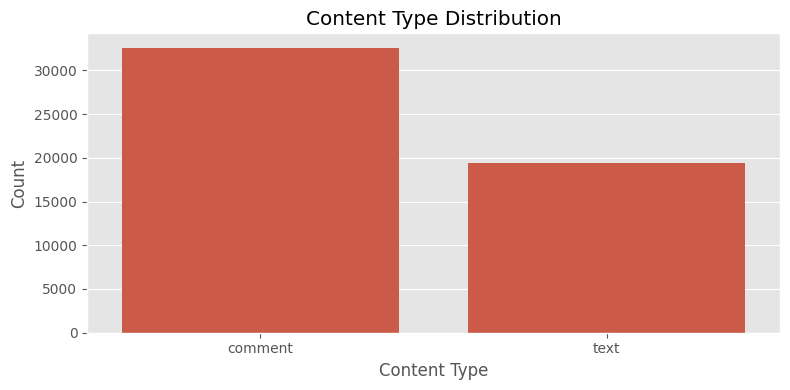

In [37]:

# ========== Content Type ==========
plt.figure(figsize=(8,4))
sns.countplot(data=df_unique, x="content_type", order=df_unique["content_type"].value_counts().index)
plt.title("Content Type Distribution")
plt.xlabel("Content Type")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

In [11]:
texts = df['text'].tolist()

outputs = classifier(texts, truncation=True, max_length=512)
outputs, texts

([{'label': 'safe', 'score': 0.9002366662025452},
  {'label': 'safe', 'score': 0.9601740837097168},
  {'label': 'safe', 'score': 0.9702634811401367},
  {'label': 'safe', 'score': 0.6663143038749695},
  {'label': 'safe', 'score': 0.9161384701728821},
  {'label': 'unsafe', 'score': 0.5709618330001831},
  {'label': 'safe', 'score': 0.8818644881248474},
  {'label': 'safe', 'score': 0.6026462316513062},
  {'label': 'unsafe', 'score': 0.7811041474342346},
  {'label': 'unsafe', 'score': 0.9526394009590149},
  {'label': 'safe', 'score': 0.7027769088745117},
  {'label': 'unsafe', 'score': 0.7341701984405518},
  {'label': 'safe', 'score': 0.6019474864006042},
  {'label': 'safe', 'score': 0.5141167640686035},
  {'label': 'unsafe', 'score': 0.7879063487052917},
  {'label': 'unsafe', 'score': 0.8147857785224915},
  {'label': 'unsafe', 'score': 0.655625581741333},
  {'label': 'unsafe', 'score': 0.6266966462135315},
  {'label': 'unsafe', 'score': 0.8237149715423584},
  {'label': 'safe', 'score': 0.88

In [12]:
labels = [o['label'] for o in outputs]
scores = [o['score'] for o in outputs]

df['pred_label'] = labels
df['pred_score'] = scores

df.to_csv("services/visualization/outputs/classified_output.csv", index=False)